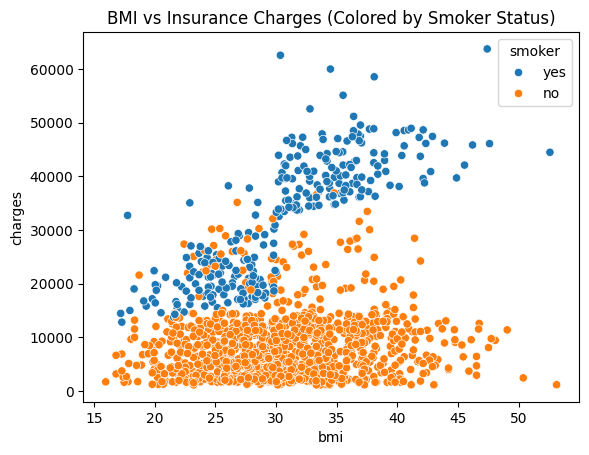

MAE: $4181.19
RMSE: $5796.28


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load the dataset using the relative path
# Since your notebook is likely in the 'Developers Internship' folder:
df = pd.read_csv('archive/insurance.csv')

# 1. Visualization: BMI vs Charges
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Insurance Charges (Colored by Smoker Status)')
plt.show()

# 2. Data Preparation
# Convert categorical text into numbers for the model
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']

# 3. Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
print(f"MAE: ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")